In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [27]:
# Load cleaned dataset
file_path = r"D:\Work - 2026\credit-risk-ml\data\processed\credit_default_clean.csv"
df = pd.read_csv(file_path)

print("Shape:", df.shape)
df.head()

Shape: (30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_payment_next_month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [28]:
# Check columns
print(df.columns.tolist())

['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default_payment_next_month']


In [29]:
# Separate features and target
X = df.drop("default_payment_next_month", axis=1)
y = df["default_payment_next_month"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (30000, 23)
y shape: (30000,)


In [30]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (24000, 23)
X_test shape: (6000, 23)
y_train shape: (24000,)
y_test shape: (6000,)


In [31]:
# Scale data for Logistic Regression
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")

Scaling complete.


In [32]:
# Logistic Regression model
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [33]:
# Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [34]:
# Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=8
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [35]:
# Function to evaluate model
def evaluate_model(y_true, y_pred, y_prob, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)

    print(f"\n{model_name} Results")
    print("-" * 40)
    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1-score :", f1)
    print("ROC-AUC  :", roc_auc)

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC": roc_auc
    }
    

In [36]:
# Evaluate Logistic Regression
log_results = evaluate_model(y_test, y_pred_log, y_prob_log, "Logistic Regression")


Logistic Regression Results
----------------------------------------
Accuracy : 0.8083333333333333
Precision: 0.6903225806451613
Recall   : 0.24189902034664656
F1-score : 0.35825892857142855
ROC-AUC  : 0.707924808472601


In [37]:
# Evaluate Decision Tree
dt_results = evaluate_model(y_test, y_pred_dt, y_prob_dt, "Decision Tree")


Decision Tree Results
----------------------------------------
Accuracy : 0.8171666666666667
Precision: 0.6615168539325843
Recall   : 0.3549359457422758
F1-score : 0.46199117214320745
ROC-AUC  : 0.7418215337318345


In [38]:
# Evaluate Random Forest
rf_results = evaluate_model(y_test, y_pred_rf, y_prob_rf, "Random Forest")


Random Forest Results
----------------------------------------
Accuracy : 0.8171666666666667
Precision: 0.6666666666666666
Recall   : 0.346646571213263
F1-score : 0.4561229548834903
ROC-AUC  : 0.7718118370197664


In [39]:
# Compare all models
results_df = pd.DataFrame([log_results, dt_results, rf_results])
results_df.sort_values(by="ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
2,Random Forest,0.817167,0.666667,0.346647,0.456123,0.771812
1,Decision Tree,0.817167,0.661517,0.354936,0.461991,0.741822
0,Logistic Regression,0.808333,0.690323,0.241899,0.358259,0.707925


In [40]:
# Classification report - Logistic Regression
print("Logistic Regression Classification Report")
print(classification_report(y_test, y_pred_log))

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.69      0.24      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.75      0.61      0.62      6000
weighted avg       0.79      0.81      0.77      6000



In [41]:
# Classification report - Decision Tree
print("Decision Tree Classification Report")
print(classification_report(y_test, y_pred_dt))

Decision Tree Classification Report
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.66      0.35      0.46      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000



In [42]:
# Classification report - Random Forest
print("Random Forest Classification Report")
print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.67      0.35      0.46      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.67      6000
weighted avg       0.80      0.82      0.79      6000



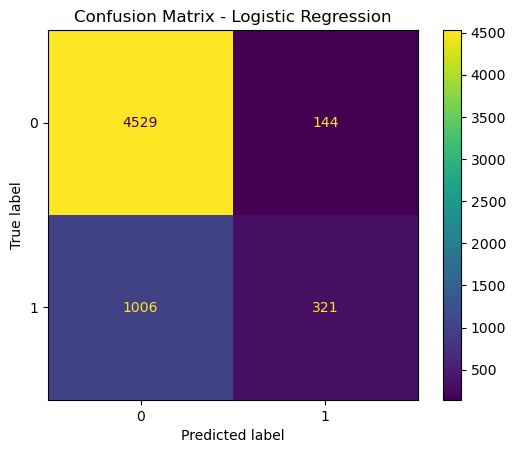

In [43]:
# Confusion Matrix - Logistic Regression
cm_log = confusion_matrix(y_test, y_pred_log)
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log)
disp_log.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

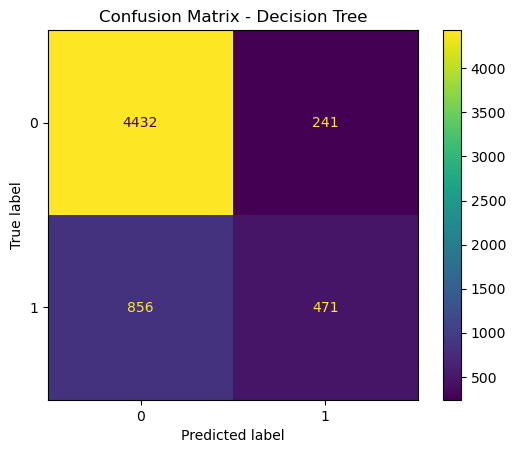

In [44]:
# Confusion Matrix - Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt)
disp_dt.plot()
plt.title("Confusion Matrix - Decision Tree")
plt.show()

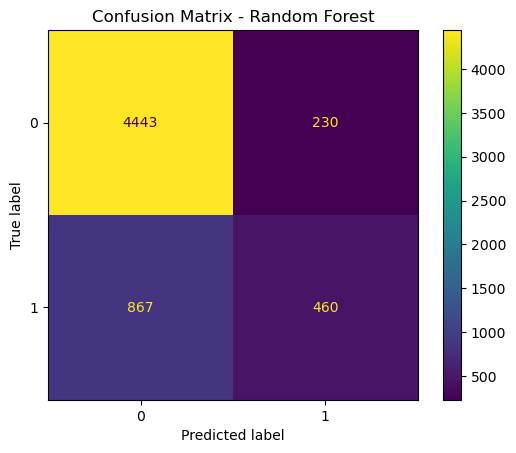

In [45]:
# Confusion Matrix - Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [46]:
# Feature importance from Random Forest
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance.head(10)

,Feature,Importance
5,PAY_0,0.303047
6,PAY_2,0.140470
8,PAY_4,0.064549
7,PAY_3,0.058406
9,PAY_5,0.049055
10,PAY_6,0.048350
0,LIMIT_BAL,0.037236
17,PAY_AMT1,0.033574
18,PAY_AMT2,0.027605
11,BILL_AMT1,0.027020


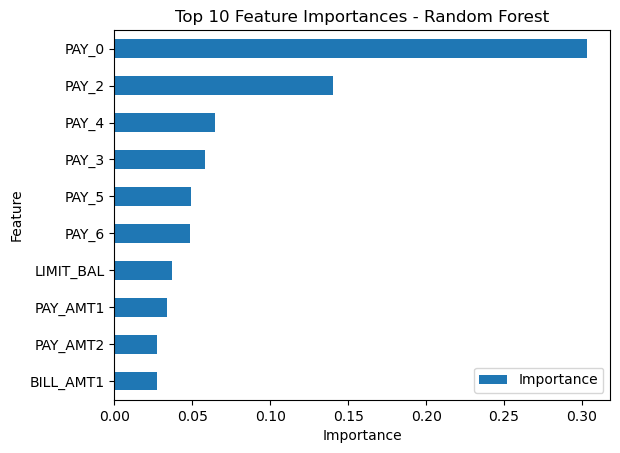

In [47]:
# Plot top 10 important features
top_features = feature_importance.head(10).sort_values(by="Importance")

top_features.plot(kind="barh", x="Feature", y="Importance")
plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [48]:
# Save model comparison results
results_path = r"D:\Work - 2026\credit-risk-ml\data\processed\model_results.csv"
results_df.to_csv(results_path, index=False)

print(f"Model results saved at: {results_path}")

Model results saved at: D:\Work - 2026\credit-risk-ml\data\processed\model_results.csv


In [49]:
# # Save feature importance
feature_path = r"D:\Work - 2026\credit-risk-ml\data\processed\feature_importance.csv"
feature_importance.to_csv(feature_path, index=False)

print(f"Feature importance saved at: {feature_path}")
feature_path = r"D:\Work - 2026\credit-risk-ml\data\processed\feature_importance.csv"
feature_importance.to_csv(feature_path, index=False)

print(f"Feature importance saved at: {feature_path}")

Feature importance saved at: D:\Work - 2026\credit-risk-ml\data\processed\feature_importance.csv
Feature importance saved at: D:\Work - 2026\credit-risk-ml\data\processed\feature_importance.csv


In [50]:
print("Modeling completed successfully.")
print("\nFinal model comparison:")
print(results_df.sort_values(by="ROC-AUC", ascending=False))


Modeling completed successfully.

Final model comparison:
                 Model  Accuracy  Precision    Recall  F1-score   ROC-AUC
2        Random Forest  0.817167   0.666667  0.346647  0.456123  0.771812
1        Decision Tree  0.817167   0.661517  0.354936  0.461991  0.741822
0  Logistic Regression  0.808333   0.690323  0.241899  0.358259  0.707925


In [51]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

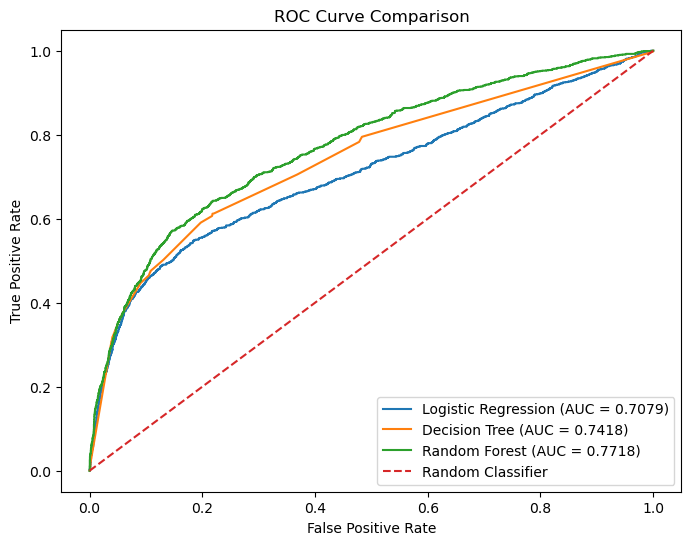

In [52]:
# ROC Curve for all models
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_log):.4f})")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {roc_auc_score(y_test, y_prob_dt):.4f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

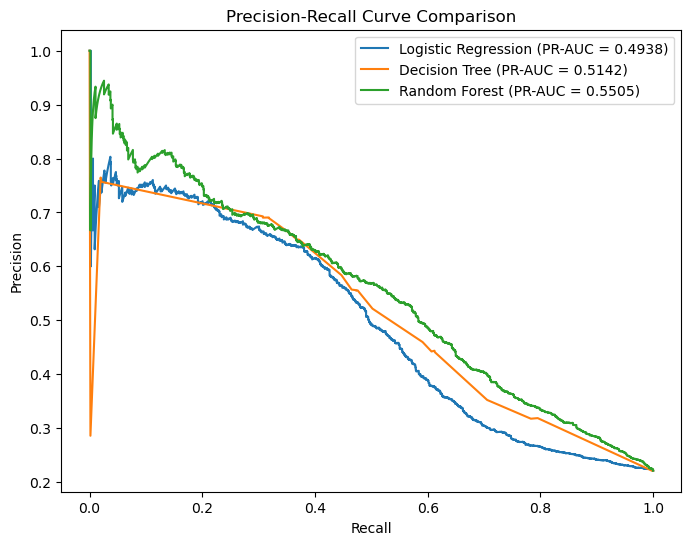

In [53]:
# Precision-Recall Curve for all models
precision_log, recall_log, _ = precision_recall_curve(y_test, y_prob_log)
precision_dt, recall_dt, _ = precision_recall_curve(y_test, y_prob_dt)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)

pr_auc_log = auc(recall_log, precision_log)
pr_auc_dt = auc(recall_dt, precision_dt)
pr_auc_rf = auc(recall_rf, precision_rf)

plt.figure(figsize=(8, 6))
plt.plot(recall_log, precision_log, label=f"Logistic Regression (PR-AUC = {pr_auc_log:.4f})")
plt.plot(recall_dt, precision_dt, label=f"Decision Tree (PR-AUC = {pr_auc_dt:.4f})")
plt.plot(recall_rf, precision_rf, label=f"Random Forest (PR-AUC = {pr_auc_rf:.4f})")

plt.title("Precision-Recall Curve Comparison")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

In [54]:
# Gini Coefficient
gini_log = 2 * roc_auc_score(y_test, y_prob_log) - 1
gini_dt = 2 * roc_auc_score(y_test, y_prob_dt) - 1
gini_rf = 2 * roc_auc_score(y_test, y_prob_rf) - 1

print("Gini Coefficients")
print("-" * 30)
print(f"Logistic Regression: {gini_log:.4f}")
print(f"Decision Tree      : {gini_dt:.4f}")
print(f"Random Forest      : {gini_rf:.4f}")

Gini Coefficients
------------------------------
Logistic Regression: 0.4158
Decision Tree      : 0.4836
Random Forest      : 0.5436


In [55]:
# KS Statistic function
def ks_statistic(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    ks = max(tpr - fpr)
    ks_threshold = thresholds[np.argmax(tpr - fpr)]
    return ks, ks_threshold

In [56]:
# KS Statistic for all models
ks_log, ks_thresh_log = ks_statistic(y_test, y_prob_log)
ks_dt, ks_thresh_dt = ks_statistic(y_test, y_prob_dt)
ks_rf, ks_thresh_rf = ks_statistic(y_test, y_prob_rf)

print("KS Statistics")
print("-" * 30)
print(f"Logistic Regression: KS = {ks_log:.4f}, Threshold = {ks_thresh_log:.4f}")
print(f"Decision Tree      : KS = {ks_dt:.4f}, Threshold = {ks_thresh_dt:.4f}")
print(f"Random Forest      : KS = {ks_rf:.4f}, Threshold = {ks_thresh_rf:.4f}")

KS Statistics
------------------------------
Logistic Regression: KS = 0.3638, Threshold = 0.2532
Decision Tree      : KS = 0.3938, Threshold = 0.2174
Random Forest      : KS = 0.4250, Threshold = 0.2583


In [57]:
# Add professional metrics to comparison table
results_df["PR-AUC"] = [pr_auc_log, pr_auc_dt, pr_auc_rf]
results_df["Gini"] = [gini_log, gini_dt, gini_rf]
results_df["KS"] = [ks_log, ks_dt, ks_rf]

results_df.sort_values(by="ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC,Gini,KS
2,Random Forest,0.817167,0.666667,0.346647,0.456123,0.771812,0.550477,0.543624,0.424952
1,Decision Tree,0.817167,0.661517,0.354936,0.461991,0.741822,0.514214,0.483643,0.393845
0,Logistic Regression,0.808333,0.690323,0.241899,0.358259,0.707925,0.493766,0.415850,0.363816


In [58]:
# Save updated comparison results
results_path = r"D:\Work - 2026\credit-risk-ml\data\processed\model_results_detailed.csv"
results_df.to_csv(results_path, index=False)

print(f"Detailed model results saved at: {results_path}")

Detailed model results saved at: D:\Work - 2026\credit-risk-ml\data\processed\model_results_detailed.csv
